# Multi-GEOFF Experiment 1 — Can Autostep separate useful from useless connections?

Everything in the [multi-GEOFF plan](multi_geoff_experiment_plan.md) depends on step-size
adaptation working, so this notebook is the gating check. The problem is 2-task non-stationary
**multi-GEOFF** (`phd/jax_core/tasks/multi_geoff.py`): the target is two independent GEOFF
sub-networks ("slots") with block-diagonal teacher connectivity and per-output squared error,
and every 1,000 steps one slot's readout columns are permuted (each slot on average once every
2,000 steps, via `perturbation_period(2000, 2)`).

The learner is a masked two-layer MLP whose **base structure is block-sparse** — each hidden
unit fully connected to its own task's inputs and outputs. Because that gives every hidden unit
a single subtask, any cross-task connection added on top of it is *useless by construction*.
That is the whole point: relevance is known, so step-size adaptation can be graded against it.

### Sub-experiments

* **1a — mixed-relevance network from scratch.** ⅓ of hidden units additionally fully connected
  to the other task's outputs, ⅓ to the other task's inputs, ⅓ left clean. Trained from scratch.
* **1b — bad connections added mid-training.** Start from the *clean* block-sparse structure,
  train until the performance level is stable, then give every hidden unit 1–3 new outgoing
  connections to the other task's outputs and 1–10 new incoming connections from the other
  task's inputs. Those connections are bad but not strictly useless — each affected unit now
  reads some of the other task's inputs *and* feeds some of its outputs, so there is some
  incentive for the weights to move off zero. The best solution still holds them all at 0.

### The two Autostep-for-networks variants

Autostep is derived for the linear case; extending it to a network means approximating the
update for *h* to avoid a hessian term. Both plots below are produced for both variants.

* **Variant A** (`version='prediction_grads'`) — drop the hessian term entirely; the normalizer
  uses squared prediction gradients.
* **Variant B** (`version='squared_inputs'`) — treat each layer as its own independent linear
  problem: wherever linear Autostep uses the squared input x², use the squared value of the
  weight's *source unit* (network inputs for first-layer weights, hidden-unit values for
  second-layer weights). Ported to `optax_idbd` from the mode of the same name in this repo's
  original torch IDBD.

### How the runs are cached

Each configuration runs `N_SEEDS` seeds batched into one jitted `jax.lax.scan` and is driven
through an **mlflow-sweeper** sweep, so the experiments only execute on the first run — later
executions find the studies complete and reload the cached metrics. Per-connection *traces*
are far too many series for a metric store, so the same run caches them to `.npz` next to the
metrics (see `experiment_logging.save_traces`); nothing is ever replayed.

In [1]:
import logging
import os
import sys
from dataclasses import dataclass

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optax
import pandas as pd
import seaborn as sns
from omegaconf import OmegaConf

from mlflow_sweeper import SweepConfig, run_sweep, delete_sweep

from phd.jax_core.optimizers.idbd import optax_idbd
from phd.jax_core.tasks.multi_geoff import MultiGEOFFTask, perturbation_period
from phd.jax_core.utils import stack_pytrees, tree_replace
from phd.research_utils.scripts.mlflow_download import download_experiment
from phd.research_utils.analysis.analysis_utils import load_experiment_data, get_color_palette

NOTEBOOK_DIR = os.path.abspath('.')
if NOTEBOOK_DIR not in sys.path:      # make the sibling modules importable
    sys.path.insert(0, NOTEBOOK_DIR)

from masked_mlp import (
    INACTIVE, USEFUL, USELESS, MaskedTwoLayerMLP, add_random_cross_task_connections,
    added_connection_labels, block_sparse_masks, connection_labels, contaminate_masks,
    gather_at, masked_quantiles, reset_idbd_state_at, slot_ids, subsample_indices,
    thirds_group_ids,
)
from experiment_logging import (
    load_traces, log_curves, plot_group_bands, plot_learning_curve, plot_traces, save_traces,
    summarize_runs,
)

sns.set_theme('notebook', 'white')
%matplotlib inline

# Variant A knowingly applies Autostep across two layers, which is exactly what `optax_idbd`
# warns about; the warning would otherwise fire on every trace.
logging.getLogger('phd.jax_core.optimizers.idbd').setLevel(logging.ERROR)

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Sweep state and metrics go to the **shared PostgreSQL mlflow-sweeper server** by default, read
from the `MLFLOW_TRACKING_URI` / `OPTUNA_TRACKING_URI` environment variables. Set
`USE_LOCAL_STORES = True` to fall back to sqlite files next to this notebook instead — useful for
throwaway runs you do not want in the shared store. Note the env vars are *read*, never
overwritten, so this notebook cannot clobber the session's server configuration.

Per the plan's common experimental settings: the non-stationary problem everywhere, multi-GEOFF
task defaults (20 inputs and 10 outputs per task, `noise_std=1`), Autostep for everything, and
an initial step-size fixed at **1e-6** for every connection including ones added mid-training —
never swept.

**`NUM_STEPS` is tied to `INIT_LR`** — shrink one and you must grow the other. `h_decay_term` is
the only thing the two variants disagree about, and it enters Autostep *exclusively* through
terms scaled by α (the `h`-trace decay `h·[1 − α·d]₊`, the `v`-trace coefficient `α·d/τ`, and the
`Σ α·d` normalizer, clipped below at 1); the meta-update `α ← α·exp(η·h·g/v)` does not involve
`d` at all. So while α is tiny the variants are numerically indistinguishable, and α climbs at a
roughly constant rate *in log space* (`h·g/v` is scale-free, since `h ∝ α` and `v ∝ |h·g|`).
Measured final useful/useless step-size ratios (w1, w2):

| initial α | steps | Variant A | Variant B |
|---|---|---|---|
| 1e-5 | 1M | 2.26, 1.95 | 3.40, 2.06 |
| 1e-6 | 1M | 4.48, 1.60 | 4.54, 1.74 |
| 1e-6 | 3M | 2.55, 2.94 | 3.03, 4.54 |

At 1e-6 a 1M-step run would say nothing about the variants; by 3M they are clearly apart. The
ratio is also **not monotone** — it peaks then compresses as both groups grow — so read the
distribution figures rather than treating the final ratio as a score.

In [2]:
EXPERIMENT = 'multi-geoff-experiment-1'
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'data')
SWEEP_OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, 'sweep_output')
OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, 'output')      # only used by the local-store fallback

# Every directory must exist before a sqlite URI is used: sqlite will not create a missing parent
# directory and fails with "unable to open database file".
for _dir in (DATA_DIR, SWEEP_OUTPUT_DIR, OUTPUT_DIR):
    os.makedirs(_dir, exist_ok=True)

# Default to the shared PostgreSQL server, falling back to local sqlite files if the environment
# does not define it. The env vars are only ever read here — never assigned — so running this
# notebook cannot repoint the session's tracking server.
USE_LOCAL_STORES = False

if USE_LOCAL_STORES:
    MLFLOW_URI = f"sqlite:///{os.path.join(OUTPUT_DIR, 'mlruns.db')}"
    OPTUNA_URI = f"sqlite:///{os.path.join(OUTPUT_DIR, 'optuna.db')}"
else:
    MLFLOW_URI = os.environ.get(
        'MLFLOW_TRACKING_URI', f"sqlite:///{os.path.join(OUTPUT_DIR, 'mlruns.db')}")
    OPTUNA_URI = os.environ.get(
        'OPTUNA_TRACKING_URI', f"sqlite:///{os.path.join(OUTPUT_DIR, 'optuna.db')}")

mlflow.set_tracking_uri(MLFLOW_URI)

# --- Problem (multi-GEOFF defaults, non-stationary) ---
N_TASKS = 2
N_FEATURES_PER_TASK = 20
N_OUTPUTS_PER_TASK = 10
NOISE_STD = 1.0
PER_TASK_PERTURB_PERIOD = 2000
PERTURB_PERIOD = perturbation_period(PER_TASK_PERTURB_PERIOD, N_TASKS)   # -> 1000

N_OUTPUTS = N_TASKS * N_OUTPUTS_PER_TASK

# --- Learner ---
N_HIDDEN = 64
ACTIVATION = 'leaky_relu'
INIT_LR = 1e-6           # fixed everywhere, never swept
META_LR_GRID = [0.001, 0.002, 0.005, 0.01, 0.02]
L1_COEFF = 0.01          # L1 penalty for the 1a + L1 section

# --- Training / logging ---
NUM_STEPS = 3_000_000
BATCH_SIZE = 1           # online; also required, `generate_batch` asserts batch_size <= period
N_SNAPSHOTS = 250        # connectivity snapshots per run
N_LOG_POINTS = 250       # binned points logged for the per-step series
N_SWEEP_SEEDS = 10       # seeds per configuration of the meta step-size sweep
N_MAIN_SEEDS = 30        # seeds for the 1a / 1b runs
N_SWEEP_JOBS = 1         # concurrent trials per sweep; see the note below on why 1
N_TRACES = 30            # individual connections traced per layer per group
FINAL_FRACTION = 0.05
BASE_SEED = 0

LAYERS = ('w1', 'w2')
LAYER_NAMES = ('input layer (hidden $\\leftarrow$ inputs)',
               'output layer (outputs $\\leftarrow$ hidden)')
GROUPS = (USEFUL, USELESS)
QUANTILES = (0.1, 0.25, 0.5, 0.75, 0.9)
MEDIAN_IDX = QUANTILES.index(0.5)
VERSIONS = {'variant_a': 'prediction_grads', 'variant_b': 'squared_inputs'}
VARIANT_LABELS = {'variant_a': 'Variant A (prediction grads)',
                  'variant_b': 'Variant B (squared source values)'}

# Per-output MSE reference points. The irreducible MSE is `noise_std**2 = 1` exactly, so an
# optimal predictor sits at MSE 1 (FVE 1) on every draw. The mean predictor sits at MSE 2 (FVE 0)
# only *in expectation over teachers*: `output_weight_scale` gives unit per-output signal variance
# in expectation, and a single teacher's variance scatters around 1 by order 10%
# (`tests/test_multi_geoff_task.py::test_fraction_variance_explained_calibration`). So treat the
# MSE-2 line as approximate per seed, though it is a fine convergence threshold across 5-10 seeds.
# A run that ends above it has not learned anything.
IRREDUCIBLE_MSE = NOISE_STD ** 2
BASELINE_MSE = IRREDUCIBLE_MSE + 1.0

INPUT_TASK_IDS = slot_ids(N_TASKS, N_FEATURES_PER_TASK)
OUTPUT_TASK_IDS = slot_ids(N_TASKS, N_OUTPUTS_PER_TASK)

BASE_SWEEP_CONFIG = {
    'experiment': EXPERIMENT,
    'optuna_storage': OPTUNA_URI,
    'mlflow_storage': MLFLOW_URI,
    'output_dir': SWEEP_OUTPUT_DIR,
    'algorithm': 'grid',
    'spec': {'direction': 'minimize', 'metric': 'final_loss'},
}
print('MLflow store        :', MLFLOW_URI)
print('Optuna store        :', OPTUNA_URI)
print('Perturbation period :', PERTURB_PERIOD, 'steps (global)')
print('Mean-predictor MSE  :', BASELINE_MSE, ' | irreducible MSE:', IRREDUCIBLE_MSE)

INFO:2026-07-29 20:06:00,209:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


MLflow store        : postgresql:///mlflow?host=/var/run/postgresql&port=5433
Optuna store        : postgresql:///optuna?host=/var/run/postgresql&port=5433
Perturbation period : 1000 steps (global)
Mean-predictor MSE  : 2.0  | irreducible MSE: 1.0


## Connectivity structures

Three structures, all built from the same block-sparse base:

| structure | used by | useless connections |
|---|---|---|
| `base_masks` | 1b pre-training | none — pure block-sparse |
| `masks_1a` | 1a | the contamination added to ⅓ + ⅓ of hidden units |
| `masks_1b` | 1b post-injection | the randomly injected cross-task connections |

64 hidden units do not divide into thirds, so the split is done *within* each task — 32 units
per task, in groups of 10 / 11 / 11.

In [3]:
base_masks, hidden_task_ids = block_sparse_masks(
    N_TASKS, N_FEATURES_PER_TASK, N_OUTPUTS_PER_TASK, N_HIDDEN)
group_ids = thirds_group_ids(hidden_task_ids, N_TASKS)

masks_1a = contaminate_masks(
    base_masks, hidden_task_ids, group_ids, INPUT_TASK_IDS, OUTPUT_TASK_IDS)
labels_1a = connection_labels(masks_1a, hidden_task_ids, INPUT_TASK_IDS, OUTPUT_TASK_IDS)

masks_1b, added_1b = add_random_cross_task_connections(
    base_masks, hidden_task_ids, INPUT_TASK_IDS, OUTPUT_TASK_IDS,
    jax.random.PRNGKey(BASE_SEED))
# In 1b the split of interest is original-vs-added rather than same-task-vs-cross-task. The two
# coincide here, because the pre-existing structure is pure block-sparse.
labels_1b = added_connection_labels(masks_1b, added_1b)


def describe(name, labels):
    for layer in LAYERS:
        lab = labels[layer]
        print(f'  {name:8s} {layer}  useful {int((lab == USEFUL).sum()):5d}   '
              f'useless {int((lab == USELESS).sum()):5d}   '
              f'inactive {int((lab == INACTIVE).sum()):5d}')


print('hidden units per task :', N_HIDDEN // N_TASKS)
print('contamination groups  : extra-outputs / extra-inputs / clean =',
      [int((group_ids == g).sum()) for g in (0, 1, 2)])
describe('1a', labels_1a)
describe('1b', labels_1b)
print('1b added per hidden unit: incoming '
      f'{int(added_1b["w1"].sum(1).min())}-{int(added_1b["w1"].sum(1).max())}, outgoing '
      f'{int(added_1b["w2"].sum(0).min())}-{int(added_1b["w2"].sum(0).max())}')

hidden units per task : 32
contamination groups  : extra-outputs / extra-inputs / clean = [20, 22, 22]
  1a       w1  useful  1280   useless   440   inactive   840
  1a       w2  useful   640   useless   200   inactive   440
  1b       w1  useful  1280   useless   327   inactive   953
  1b       w2  useful   640   useless   120   inactive   520
1b added per hidden unit: incoming 1-10, outgoing 1-3


## The learner

A masked two-layer MLP (`masked_mlp.MaskedTwoLayerMLP`) trained online with Autostep, one
sample at a time. Connectivity is a float 0/1 mask multiplied into the weights at forward time,
so an arbitrary per-connection topology is expressible and a single connection can be toggled
with an `.at[]` write. The trainable weights live in a plain `dict` handed straight to the
optimizer, which keeps the masks out of the parameter tree entirely.

The two variants differ in exactly one call. Note what makes Variant B free: the forward pass
already returns `param_inputs` — the value of each weight's source units — because that *is*
the curvature basis Variant B needs.

Both layers are initialized `lecun_uniform`, not zeros: with a zero second layer the *prediction*
gradients of the first layer are identically zero, which would pin Variant A's first-layer
step-sizes at their initial value for as long as the second layer stayed near zero.

In [4]:
class AutostepMLP(eqx.Module):
    """Masked two-layer MLP trained online with Autostep, under either network variant."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    version: str = eqx.field(static=True)
    l1: float = eqx.field(static=True)
    model: MaskedTwoLayerMLP
    opt_state: optax.OptState

    @classmethod
    def init(cls, masks, meta_lr, version, key, l1=0.0):
        optimizer = optax_idbd(init_lr=INIT_LR, meta_lr=meta_lr, autostep=True, version=version)
        model = MaskedTwoLayerMLP(masks, activation=ACTIVATION, key=key)
        return cls(optimizer=optimizer, version=version, l1=l1, model=model,
                   opt_state=optimizer.init(model.weights))

    def step(self, x, y):
        """One online update. Returns the new learner and the squared error summed over outputs."""
        def loss_fn(weights):
            out, param_inputs = tree_replace(self.model, weights=weights)(x)
            # Summed over outputs, matching the convention in structure_search/train.py.
            return jnp.sum((out - y) ** 2), param_inputs

        (loss, param_inputs), grads = jax.value_and_grad(loss_fn, has_aux=True)(self.model.weights)

        if self.l1 > 0.0:
            # L1 enters as a subgradient on the gradient Autostep consumes, not as a term in the
            # returned loss: `loss` stays pure squared error, so MSE and FVE remain directly
            # comparable to a run without L1. Note the coupling this creates — `loss_grads` also
            # drives Autostep's h / v traces and its meta-update, so the penalty shapes step-size
            # adaptation as well as shrinking weights. Masking keeps masked-out positions inert
            # (sign(0) is already 0, so it is belt-and-braces).
            grads = {k: g + self.l1 * jnp.sign(self.model.weights[k]) * self.model.masks[k]
                     for k, g in grads.items()}

        if self.version == 'prediction_grads':
            # Variant A: drop the hessian term; the normalizer uses squared prediction gradients.
            pred_grads = jax.grad(
                lambda w: jnp.sum(tree_replace(self.model, weights=w)(x)[0])
            )(self.model.weights)
            updates, opt_state = self.optimizer.update(
                (grads, pred_grads), self.opt_state, self.model.weights)
        else:
            # Variant B: each layer is its own linear problem, so the normalizer uses the squared
            # value of each weight's source unit — already returned by the forward pass.
            updates, opt_state = self.optimizer.update(
                (grads, None, param_inputs), self.opt_state, self.model.weights)

        weights = {k: self.model.weights[k] + updates[k] for k in updates}
        return (tree_replace(self, model=tree_replace(self.model, weights=weights),
                             opt_state=opt_state),
                loss)

## Run machinery

`run_phase` is a **nested scan**: an inner scan of `NUM_STEPS // N_SNAPSHOTS` steps emitting only
the scalar loss, wrapped in an outer scan emitting one connectivity snapshot per block. That is
what makes per-connection tracing affordable — the network has 64×40 + 20×64 = 3,840 weights, so
a per-step record is not storable, but 250 snapshots is nothing. (Same trick
`structure_search/train.py` uses to keep its restructure step on a statically-traced path.)

Each snapshot records, per layer and per group, the quantiles of the step-sizes and of the
absolute weights, plus the values of `N_TRACES` *fixed* individual connections — fixed so the
traces follow the same connections for the whole run.

One independent teacher is built per seed and the seeds are `vmap`ped together.
`MultiGEOFFTask` takes an integer seed rather than a PRNG key, so the tasks are constructed
outside `jit` and stacked with `stack_pytrees`.

In [5]:
def make_trace_idxs(labels, seed=BASE_SEED):
    """Fix which individual connections are traced, once, outside of `jit`."""
    idxs = {}
    for layer in LAYERS:
        idxs[layer] = {}
        for group in GROUPS:
            picked = subsample_indices(labels[layer], group, N_TRACES, seed=seed)
            n = 0 if picked is None else picked.shape[0]
            assert n == N_TRACES, \
                f"Layer {layer} group {group} has {n} connections, fewer than N_TRACES={N_TRACES}!"
            idxs[layer][group] = picked
    return idxs


def snapshot(learner, labels, trace_idxs):
    """Per-group quantiles and the fixed subsampled traces of step-sizes and |weights|."""
    alpha = {k: jnp.exp(learner.opt_state.beta[k]) for k in LAYERS}
    absw = {k: jnp.abs(learner.model.weights[k]) for k in LAYERS}

    def per_layer_and_group(fn):
        """Stack `fn(layer, group)` into shape (n_layers, n_groups, ...)."""
        return jnp.stack([jnp.stack([fn(l, g) for g in GROUPS]) for l in LAYERS])

    return {
        'alpha_q': per_layer_and_group(
            lambda l, g: masked_quantiles(alpha[l], labels[l], g, QUANTILES)),
        'absw_q': per_layer_and_group(
            lambda l, g: masked_quantiles(absw[l], labels[l], g, QUANTILES)),
        'alpha_tr': per_layer_and_group(lambda l, g: gather_at(alpha[l], trace_idxs[l][g])),
        'absw_tr': per_layer_and_group(lambda l, g: gather_at(absw[l], trace_idxs[l][g])),
    }


def run_phase(learner, task, labels, trace_idxs, n_steps, n_snapshots=N_SNAPSHOTS):
    """`n_steps` of online training, emitting the per-step loss and `n_snapshots` snapshots."""
    inner_steps = n_steps // n_snapshots
    assert inner_steps > 0 and inner_steps * n_snapshots == n_steps, \
        f"n_steps ({n_steps}) must be a multiple of n_snapshots ({n_snapshots})!"

    def inner_step(carry, _):
        learner, task = carry
        task, (x, y) = task.generate_batch(BATCH_SIZE)
        learner, loss = learner.step(x[0], y[0])
        return (learner, task), loss

    def outer_step(carry, _):
        # Snapshots are taken at the end of each block, so the last one is the final state.
        carry, losses = jax.lax.scan(inner_step, carry, length=inner_steps)
        return carry, (losses, snapshot(carry[0], labels, trace_idxs))

    carry, (losses, snaps) = jax.lax.scan(outer_step, (learner, task), length=n_snapshots)
    return carry, losses.reshape(-1), snaps


def build_tasks(n_seeds, base_seed=BASE_SEED):
    """One independent teacher per seed, stacked for `vmap`."""
    return stack_pytrees([
        MultiGEOFFTask(
            N_TASKS, perturb_period=PERTURB_PERIOD,
            n_features_per_task=N_FEATURES_PER_TASK, n_outputs_per_task=N_OUTPUTS_PER_TASK,
            noise_std=NOISE_STD, seed=base_seed + s,
        ) for s in range(n_seeds)
    ])


def snapshot_steps(n_steps, n_snapshots=N_SNAPSHOTS):
    """Step index each snapshot was taken at (the end of its block)."""
    return np.arange(1, n_snapshots + 1) * (n_steps // n_snapshots)


def per_output_mse(losses):
    """The loss is summed over outputs; every reference point is defined per output."""
    return np.asarray(losses) / N_OUTPUTS


def fve(mse):
    """Fraction of explainable variance explained: 1 for an optimal predictor, 0 for the mean."""
    return 1.0 - (np.asarray(mse) - IRREDUCIBLE_MSE)

In [6]:
def run_1a(meta_lr, version, n_seeds, n_steps=NUM_STEPS, l1=0.0,
           masks=masks_1a, labels=labels_1a):
    """Experiment 1a: train the mixed-relevance network from scratch."""
    trace_idxs = make_trace_idxs(labels)
    tasks = build_tasks(n_seeds)

    def one_seed(seed_key, task):
        learner = AutostepMLP.init(masks, meta_lr, version, seed_key, l1=l1)
        _, losses, snaps = run_phase(learner, task, labels, trace_idxs, n_steps)
        return losses, snaps

    keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), n_seeds)
    losses, snaps = jax.jit(jax.vmap(one_seed))(keys, tasks)
    return {'losses': losses, **snaps}


def run_1b(meta_lr, version, n_seeds, n_pretrain, n_steps=NUM_STEPS):
    """Experiment 1b: pre-train the clean block-sparse network, then inject bad connections."""
    trace_idxs = make_trace_idxs(labels_1b)
    tasks = build_tasks(n_seeds)

    def one_seed(seed_key, task):
        learner = AutostepMLP.init(base_masks, meta_lr, version, seed_key)
        # The pre-training phase is traced with the *post-injection* labels so the figures can
        # show the flat pre-injection baseline of the connections that do not exist yet. Those
        # positions are masked out and therefore inert, so their step-sizes sit at exactly
        # INIT_LR — asserted below.
        (learner, task), pre_losses, pre_snaps = run_phase(
            learner, task, labels_1b, trace_idxs, n_pretrain)

        # Activate the new connections. This is a one-time event at this instant, not a
        # constraint on phase 2: from here the new connections start at w = 0 with the standard
        # INIT_LR step-size and then learn exactly like any other connection — nothing pins
        # them. Both the zeroing and the state reset are in fact no-ops today, because a masked
        # connection is inert (zero gradient, so v stays 0 and Autostep leaves its step-size at
        # INIT_LR, and h stays 0), which the assertion below verifies. They are kept because
        # they state the intended initial condition explicitly, and because Experiment 2 prunes
        # and regrows connections, where a regrown position really would carry stale h / v /
        # step-size without the reset.
        model = tree_replace(
            learner.model, masks=masks_1b,
            weights={k: learner.model.weights[k] * base_masks[k] for k in LAYERS})
        learner = tree_replace(
            learner, model=model, opt_state=reset_idbd_state_at(learner.opt_state, added_1b))

        _, losses, snaps = run_phase(learner, task, labels_1b, trace_idxs, n_steps)
        return pre_losses, pre_snaps, losses, snaps

    keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), n_seeds)
    pre_losses, pre_snaps, losses, snaps = jax.jit(jax.vmap(one_seed))(keys, tasks)

    # The injected connections must be untouched before the injection, or 1b is not measuring a
    # mid-training change. This also guards the claim above that the reset is a no-op: the one way
    # a masked step-size could drift is Autostep's effective-step-size normalizer, which divides a
    # whole row once `sum(alpha * curvature)` exceeds 1. At these step-sizes that sum is ~1e-4, so
    # it never triggers — but if the scale ever changes, this assertion fires rather than silently
    # invalidating the experiment.
    pre_added_alpha = np.asarray(pre_snaps['alpha_q'])[:, -1, :, USELESS, :]
    assert np.allclose(pre_added_alpha, INIT_LR), \
        "Injected connections moved before they were activated!"

    return {'losses': losses, 'pre_losses': pre_losses,
            **snaps, **{f'pre_{k}': v for k, v in pre_snaps.items()}}

## Sweep infrastructure

**On parallelism.** `run_sweep` can run trials concurrently (`n_jobs > 1`, with
`executor='thread'` or `'process'`), but `N_SWEEP_JOBS = 1` here deliberately, because the
bottleneck is not trial-level concurrency. Every run is a `jax.lax.scan` over a *tiny* network
(64x40 + 20x64 weights), so it is latency-bound on the sequential scan rather than
throughput-bound on the GPU — measured, 3M steps takes 75.6 s at 10 seeds and 78.6 s at 30, i.e.
**vmap width is nearly free** while the step loop is not parallelizable at all (it is online
learning; step t+1 depends on t). The consequences:

* The free lever is *width*, not processes. That is why `N_MAIN_SEEDS` is 30 rather than 10 — it
  costs ~4% wall-clock and tightens every confidence interval. The same trick could batch the
  meta step-size grid into one run (5x on that phase), at the cost of one MLflow run per grid
  point, which all the analysis here relies on. Not worth it: the whole notebook is ~20 min
  serially, and it is cached after the first execution.
* `executor='process'` additionally **cannot** be used with the objectives below without
  restructuring: the process pool requires a top-level picklable function, and
  `make_objective` returns a closure over `ExpSpec` (whose `fn` is a lambda), which
  `validate_fn_picklable` rejects outright. `executor='thread'` accepts closures.
* Concurrency on a single GPU also buys little: two concurrent processes ran 2x200k steps in
  26 s vs 41 s serially, but most of that gap is overlapped interpreter/compile startup, which
  a sweep inside one notebook process does not pay per trial. Per-run compute slowed 10.3 s ->
  15 s under contention, so the real gain was ~1.4x, and both processes preallocating GPU
  memory risks OOM.

Raise `N_SWEEP_JOBS` if you move this to a many-core CPU box, where the picture reverses.

`ExpSpec` records a run: the function that executes it, its default hyperparameters, and the
label used in plots. `run_spec_sweep` turns a grid into a programmatic mlflow-sweeper sweep
whose objective logs the binned per-step series and the per-group snapshot series, and caches
the connection traces to `.npz`. `load_sweep_data` returns the standard `config_dfs` /
`run_dfs` dicts, downloading only when new runs have appeared.

`allow_param_change=True` lets an edited grid update the sweep in place: matching trials are
migrated (no recompute) and only new grid points actually run.

In [7]:
@dataclass
class ExpSpec:
    name: str                  # mlflow sweep_name
    label: str                 # human-readable label for plots
    fn: callable               # (n_seeds, **swept hyperparameters) -> dict of result arrays
    cache_traces: bool = True  # False for multi-config grids, which would overwrite each other


def log_result(result, n_steps, sweep_name, cache_traces):
    """Log a run's per-step curves, cache its per-connection snapshots, return the objective.

    The split is deliberate: MLflow gets the handful of scalar series the analysis reads back
    (`loss`, `fve`), while the ~4k per-connection values per snapshot go to a local `.npz`, which
    is what every figure below reads. Logging those to the shared metric store as well would be
    thousands of series that nothing queries.
    """
    mse = per_output_mse(result['losses'])
    series = {'loss': mse, 'fve': fve(mse)}
    if 'pre_losses' in result:
        series['pre_loss'] = per_output_mse(result['pre_losses'])

    if cache_traces:
        # Snapshot arrays only — the per-step losses are already logged in binned form and would
        # add tens of MB per run.
        save_traces(DATA_DIR, sweep_name,
                    **{k: np.asarray(v) for k, v in result.items() if not k.endswith('losses')},
                    log_steps=snapshot_steps(n_steps))

    return log_curves(series, n_log_points=N_LOG_POINTS, final_fraction=FINAL_FRACTION,
                      objective_key='loss')


def _cast(name, value):
    """Sweep parameters arrive as floats; `n_*` are counts and must stay ints (scan lengths)."""
    return int(value) if name.startswith('n_') else float(value)


def make_objective(spec):
    def objective(**params):
        kwargs = {k: _cast(k, v) for k, v in params.items()}
        return log_result(spec.fn(**kwargs), kwargs['n_steps'], spec.name, spec.cache_traces)
    return objective


def run_spec_sweep(spec, grid, n_seeds, n_steps=NUM_STEPS, n_jobs=N_SWEEP_JOBS,
                   overwrite=False):
    # Step counts belong to the sweep *identity*, not to a closure. Closing over them means that
    # changing NUM_STEPS or N_PRETRAIN_STEPS leaves the Optuna study looking complete, so a re-run
    # would silently serve results computed at the old lengths. As parameters they also show up in
    # MLflow, so every run records the lengths it was actually trained at.
    params = {**grid, 'n_seeds': int(n_seeds), 'n_steps': int(n_steps)}
    cfg = {**BASE_SWEEP_CONFIG, 'sweep_name': spec.name, 'parameters': params}
    config = SweepConfig.from_dict_config(OmegaConf.create(cfg))
    # End any lingering active run so re-running an already-complete sweep does not raise
    # "Run ... is already active".
    if mlflow.active_run() is not None:
        mlflow.end_run()
    if overwrite:
        delete_sweep(config)
    # executor='thread' is required, not incidental: the objective is a closure and the process
    # pool rejects anything that is not a top-level picklable function.
    run_sweep(config, make_objective(spec), n_jobs=n_jobs, log_params=True,
              no_plots=True, allow_param_change=True, executor='thread')


# `download_experiment` sanitizes spaces and dashes to underscores when naming its output
# (mlflow_download.py:269), so derive the CSV paths the same way rather than assuming the
# experiment name is used verbatim.
_CSV_STEM = EXPERIMENT.replace(' ', '_').replace('-', '_')
PARAMS_CSV = os.path.join(DATA_DIR, f'{_CSV_STEM}_params.csv')
METRICS_CSV = os.path.join(DATA_DIR, f'{_CSV_STEM}_metrics.csv')
RUN_COUNT_MARKER = os.path.join(DATA_DIR, f'.{_CSV_STEM}_run_count')


def _n_finished_runs():
    """Number of finished MLflow runs in the experiment (cheap; no metric history)."""
    client = mlflow.tracking.MlflowClient()
    exp = client.get_experiment_by_name(EXPERIMENT)
    if exp is None:
        return 0
    return len(client.search_runs([exp.experiment_id],
                                  filter_string="attributes.status = 'FINISHED'",
                                  max_results=50000))


def load_sweep_data(force_download=False):
    """Load the experiment's CSVs, downloading from MLflow only when new runs have appeared."""
    n_runs = _n_finished_runs()
    cached = os.path.exists(PARAMS_CSV) and os.path.exists(METRICS_CSV)
    marker = None
    if os.path.exists(RUN_COUNT_MARKER):
        with open(RUN_COUNT_MARKER) as f:
            marker = f.read().strip()

    if force_download or not cached or marker != str(n_runs):
        download_experiment(EXPERIMENT, DATA_DIR, tracking_uri=MLFLOW_URI)
        with open(RUN_COUNT_MARKER, 'w') as f:
            f.write(str(n_runs))

    return load_experiment_data(PARAMS_CSV, METRICS_CSV)

## Step 1 — meta step-size reliability check

One reliable global meta step-size is used everywhere, including the baselines and Experiment 2,
so it is chosen once here. The hard requirement from the plan is that **no runs diverge**; among
the values that satisfy that, take the one that learns best. Both variants are checked, on the
1a setup, at `N_SWEEP_SEEDS` seeds.

The initial step-size stays at 1e-6 and is not swept.

In [8]:
META_LR_SPECS = {
    key: ExpSpec(name=f'meta_lr_{key}', label=VARIANT_LABELS[key],
                 fn=lambda n_seeds, n_steps, meta_lr, _v=version: run_1a(
                     meta_lr, _v, n_seeds, n_steps),
                 cache_traces=False)
    for key, version in VERSIONS.items()
}

for spec in META_LR_SPECS.values():
    run_spec_sweep(spec, {'meta_lr': META_LR_GRID}, N_SWEEP_SEEDS)

cfgs, runs = load_sweep_data()

[I 2026-07-29 20:06:05,550] Using an existing study with name 'multi-geoff-experiment-1/meta_lr_variant_a' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: d9632262df334e19b13e3e263c6c45f2.
INFO:mlflow_sweeper.runner:Sweep run #4.
INFO:mlflow_sweeper.runner:Created trial MLflow run: adbb7300048a469191802d91e2a11f65.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(meta_lr=0.005, n_seeds=10, n_steps=3000000)`
[I 2026-07-29 20:07:34,567] Trial 4 finished with value: 1.522373784670671 and parameters: {'meta_lr': 0.005}. Best is trial 1 with value: 1.4837313350845078.
INFO:mlflow_sweeper.runner:Sweep meta_lr_variant_a completed.
[I 2026-07-29 20:07:34,732] A new study created in RDB with name: multi-geoff-experiment-1/meta_lr_variant_b
INFO:mlflow_sweeper.runner:Creating new parent MLflow run: meta_lr_variant_b.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: 73

### Learning curves per meta step-size

One panel per variant, one curve per meta step-size. This is the whole picture for a
single-variable sweep: a value that is merely *slow* is distinguishable from one that is
unstable, and the reliability table in the next cell gives the numbers.

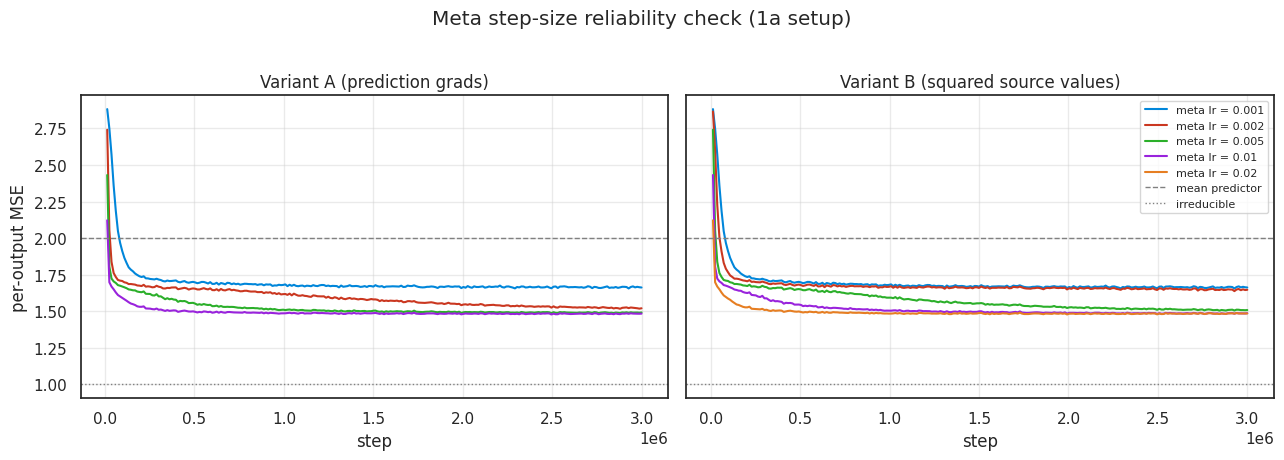

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
colors = get_color_palette(n=len(META_LR_GRID))
for ax, (key, spec) in zip(axes, META_LR_SPECS.items()):
    rdf = runs[spec.name].merge(cfgs[spec.name][['run_id', 'meta_lr']], on='run_id', how='left')
    for color, meta_lr in zip(colors, sorted(rdf['meta_lr'].astype(float).unique())):
        curve = (rdf[rdf['meta_lr'].astype(float) == meta_lr].dropna(subset=['loss'])
                 .groupby('step')['loss'].mean().sort_index())
        ax.plot(curve.index, curve.values, color=color, label=f'meta lr = {meta_lr:g}')
    ax.axhline(BASELINE_MSE, ls='--', c='gray', lw=1, label='mean predictor')
    ax.axhline(IRREDUCIBLE_MSE, ls=':', c='gray', lw=1, label='irreducible')
    ax.set_xlabel('step')
    ax.set_title(spec.label)
    ax.grid(True, alpha=0.4)
axes[0].set_ylabel('per-output MSE')
axes[-1].legend(fontsize=8)
plt.suptitle('Meta step-size reliability check (1a setup)', y=1.02)
plt.tight_layout()
plt.show()

### The chosen value

The plan's hard requirement is that **no runs diverge**, so reliability is checked before
performance. A value is reliable when, under *both* variants, (i) the final MSE is finite — a
diverged seed propagates as NaN through the across-seed mean, so divergence shows up as a
missing value rather than a large one — and (ii) the final MSE plus two across-seed standard
deviations is still below the mean predictor, which rules out a configuration whose average
looks fine only because some seeds are unstable. Among the reliable values, take the one with
the best worst-case performance across the two variants.

Everything below is pinned to the result, as are the baselines interlude and Experiment 2.

In [10]:
def pick_meta_lr(n_std=2.0):
    """Best reliable meta step-size, required to be reliable under *both* variants."""
    per_variant = {}
    for key, spec in META_LR_SPECS.items():
        summary = summarize_runs(
            cfgs, runs, spec.name, ['meta_lr'], FINAL_FRACTION, BASELINE_MSE)
        # Beyond `converged` (finite and below the mean predictor), require the upper end of the
        # across-seed spread to clear the mean predictor too, so an unstable seed disqualifies
        # the configuration rather than being averaged away.
        summary['reliable'] = summary['converged'] & (
            summary['value'] + n_std * summary['value_std'].fillna(0.0) < BASELINE_MSE)
        per_variant[key] = summary.set_index('meta_lr')

    shared = set.intersection(*[set(s.index[s['reliable']]) for s in per_variant.values()])
    if not shared:
        # Degrade rather than abort, so an unattended run still produces the 1a / 1b figures: fall
        # back to the plain `converged` rule and say so loudly. If this fires, treat the chosen
        # value as provisional and re-read the learning curves above before trusting the results.
        shared = set.intersection(*[set(s.index[s['converged']]) for s in per_variant.values()])
        print('WARNING: no meta step-size passed the strict reliability rule '
              f'(final MSE + {n_std} sd below the mean predictor). '
              'Falling back to the plain convergence rule; the choice below is provisional.')
    assert shared, "No meta step-size even converged under both variants!"
    worst = {m: max(s.loc[m, 'value'] for s in per_variant.values()) for m in shared}
    return float(min(worst, key=worst.get)), worst, per_variant


META_LR, worst_case, meta_lr_summaries = pick_meta_lr()
for key, summary in meta_lr_summaries.items():
    print(VARIANT_LABELS[key])
    print(summary[['value', 'value_std', 'converged', 'reliable']].to_string())
print('\nreliable under both variants (worst-case final MSE across variants):')
for m in sorted(worst_case):
    print(f'  meta lr {m:<8g} -> {worst_case[m]:.4f}' + ('   <- chosen' if m == META_LR else ''))
print('\nMETA_LR =', META_LR)

Variant A (prediction grads)
            value  value_std  converged  reliable
meta_lr                                          
0.020    1.483877   0.008120       True      True
0.001    1.664754   0.017656       True      True
0.010    1.491365   0.007735       True      True
0.005    1.522441   0.008710       True      True
Variant B (squared source values)
            value  value_std  converged  reliable
meta_lr                                          
0.005    1.508691   0.008772       True      True
0.001    1.664689   0.017659       True      True
0.010    1.485997   0.008031       True      True
0.020    1.485306   0.008503       True      True
0.002    1.647542   0.016404       True      True

reliable under both variants (worst-case final MSE across variants):
  meta lr 0.001    -> 1.6648
  meta lr 0.005    -> 1.5224
  meta lr 0.01     -> 1.4914
  meta lr 0.02     -> 1.4853   <- chosen

META_LR = 0.02


## Step 2 — Experiment 1a: mixed-relevance network trained from scratch

The full-seed runs at the chosen meta step-size. Each is a single-configuration sweep, so the
traces are cached and the figures below re-run nothing.

In [11]:
EXP_1A_SPECS = {
    key: ExpSpec(name=f'exp1a_{key}', label=VARIANT_LABELS[key],
                 fn=lambda n_seeds, n_steps, meta_lr, _v=version: run_1a(
                     meta_lr, _v, n_seeds, n_steps))
    for key, version in VERSIONS.items()
}

for spec in EXP_1A_SPECS.values():
    run_spec_sweep(spec, {'meta_lr': META_LR}, N_MAIN_SEEDS)

cfgs, runs = load_sweep_data()
traces_1a = {key: load_traces(DATA_DIR, spec.name) for key, spec in EXP_1A_SPECS.items()}

[I 2026-07-29 20:14:08,264] A new study created in RDB with name: multi-geoff-experiment-1/exp1a_variant_a
INFO:mlflow_sweeper.runner:Creating new parent MLflow run: exp1a_variant_a.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: 279a0832404c41228f3a4ffcc113c755.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(meta_lr=0.02, n_seeds=30, n_steps=3000000)`
[I 2026-07-29 20:15:36,478] Trial 0 finished with value: 1.4852784600725835 and parameters: {}. Best is trial 0 with value: 1.4852784600725835.
INFO:mlflow_sweeper.runner:Sweep exp1a_variant_a completed.
[I 2026-07-29 20:15:36,582] A new study created in RDB with name: multi-geoff-experiment-1/exp1a_variant_b
INFO:mlflow_sweeper.runner:Creating new parent MLflow run: exp1a_variant_b.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: cb5c8d48286f406486d9081eaf38bd19.
INFO:mlflow_sweeper.runner:Running new t

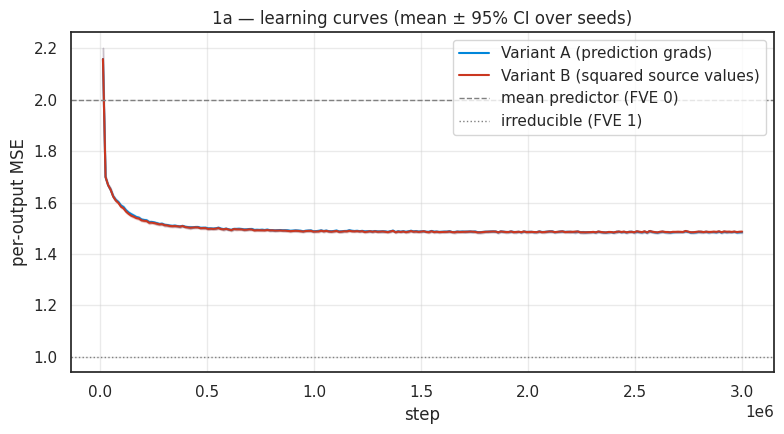

In [12]:
plt.figure(figsize=(8, 4.5))
ax = plt.gca()
for color, (key, spec) in zip(get_color_palette(n=len(EXP_1A_SPECS)), EXP_1A_SPECS.items()):
    plot_learning_curve(runs, spec.name, label=spec.label, color=color, ax=ax,
                        n_seeds=N_MAIN_SEEDS)
ax.axhline(BASELINE_MSE, ls='--', c='gray', lw=1, label='mean predictor (FVE 0)')
ax.axhline(IRREDUCIBLE_MSE, ls=':', c='gray', lw=1, label='irreducible (FVE 1)')
ax.set_ylabel('per-output MSE')
ax.set_title('1a — learning curves (mean ± 95% CI over seeds)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def show_figures(traces_by_key, specs, group_names, tag, quantity, x_offset=0):
    """Per variant: the sampled individual traces, then the group distribution, one panel per layer.

    `quantity` is 'alpha' (log axis, with the initial step-size marked) or 'absw' (linear axis,
    because zero is the correct weight for a useless connection). Shared by the two 1a sections.
    """
    ylabel, log_scale, hline = {
        'alpha': ('step-size $\\alpha$', True, INIT_LR),
        'absw': ('$|w|$', False, None),
    }[quantity]
    for key, spec in specs.items():
        t = traces_by_key[key]
        plot_traces(t[f'{quantity}_tr'], t['log_steps'], LAYER_NAMES, group_names,
                    f'{tag} {ylabel} — {spec.label} — {N_TRACES} sampled connections per group',
                    ylabel, log_scale=log_scale, x_offset=x_offset, hline=hline)
        plt.show()
        plot_group_bands(t[f'{quantity}_q'], t['log_steps'], LAYER_NAMES, group_names, QUANTILES,
                         f'{tag} {ylabel} distribution — {spec.label}', ylabel,
                         log_scale=log_scale, x_offset=x_offset, hline=hline)
        plt.show()


def separation_table(traces_by_key, specs, group_labels, run=None):
    """Median step-size and |w| per group at the final snapshot, plus the useful/useless ratio.

    A ratio above 1 means Autostep has separated the two groups. `run` optionally tags the rows,
    so two configurations can be concatenated into one table.
    """
    good, bad = group_labels
    rows = []
    for key, spec in specs.items():
        alpha = np.asarray(traces_by_key[key]['alpha_q'])[:, -1]  # (seeds, layer, group, quantile)
        absw = np.asarray(traces_by_key[key]['absw_q'])[:, -1]
        for li, layer in enumerate(LAYERS):
            med = lambda arr, g, _li=li: arr[:, _li, g, MEDIAN_IDX].mean()
            rows.append({
                **({'run': run} if run is not None else {}),
                'variant': spec.label, 'layer': layer,
                f'alpha {good}': med(alpha, 0), f'alpha {bad}': med(alpha, 1),
                'alpha ratio': med(alpha, 0) / med(alpha, 1),
                f'|w| {good}': med(absw, 0), f'|w| {bad}': med(absw, 1),
                '|w| ratio': med(absw, 0) / med(absw, 1),
            })
    return pd.DataFrame(rows)

### 1a — step-sizes over time

**Subsampled individual traces first** (the starting point for reading the result), then the
distribution over the two groups, which is the quantity actually of interest. Useful
connections in blue, useless in red; input-layer and output-layer weights in separate panels.
The dashed grey line is the initial step-size every connection starts from.

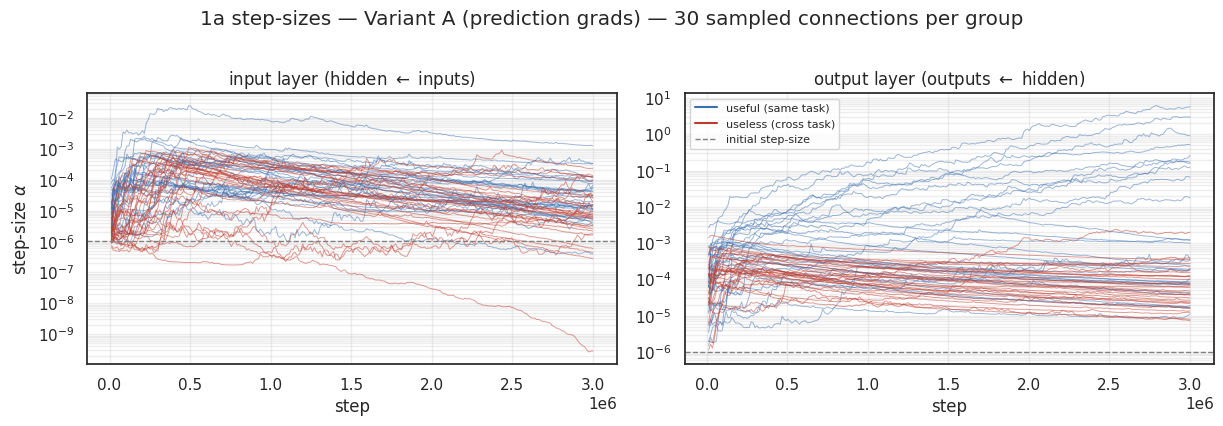

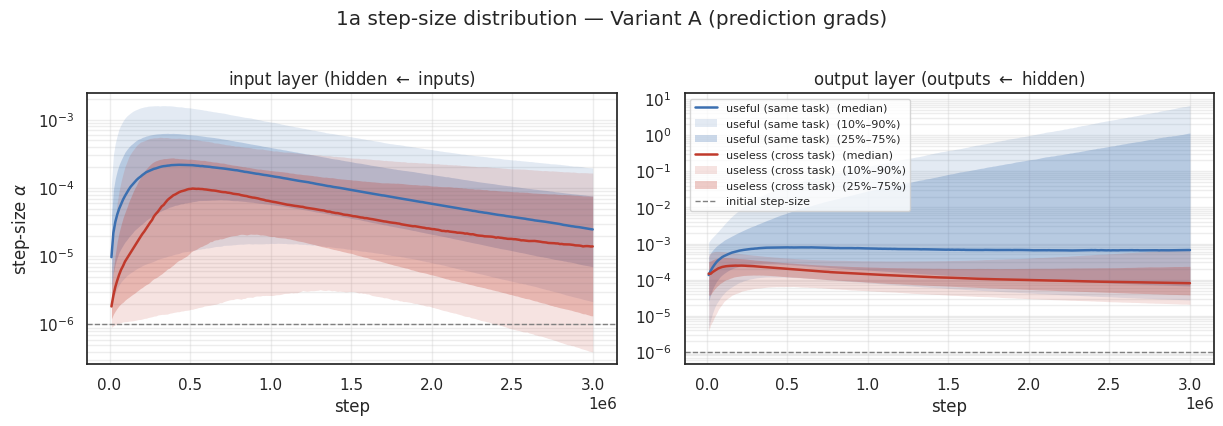

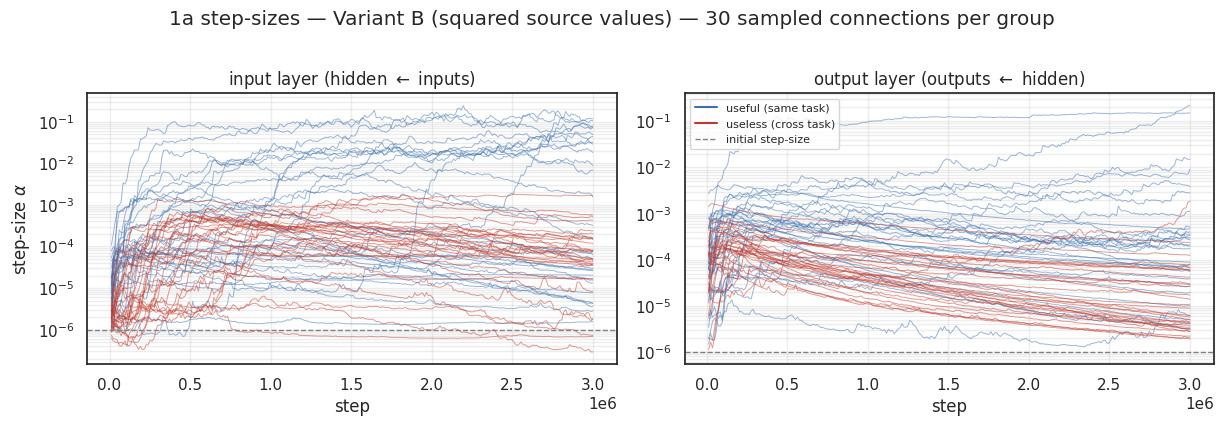

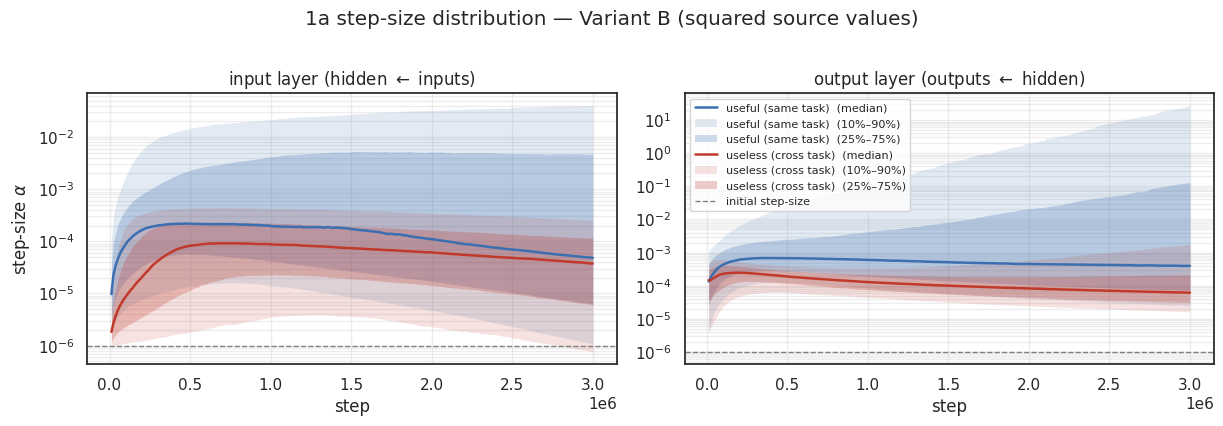

In [13]:
GROUP_NAMES_1A = ('useful (same task)', 'useless (cross task)')
show_figures(traces_1a, EXP_1A_SPECS, GROUP_NAMES_1A, '1a', 'alpha')

### 1a — weight magnitudes over time

The same two figures for $|w|$ instead of the step-size. Linear y-axis here, not log: zero is
the correct weight for a useless connection, and the magnitudes span under two decades.

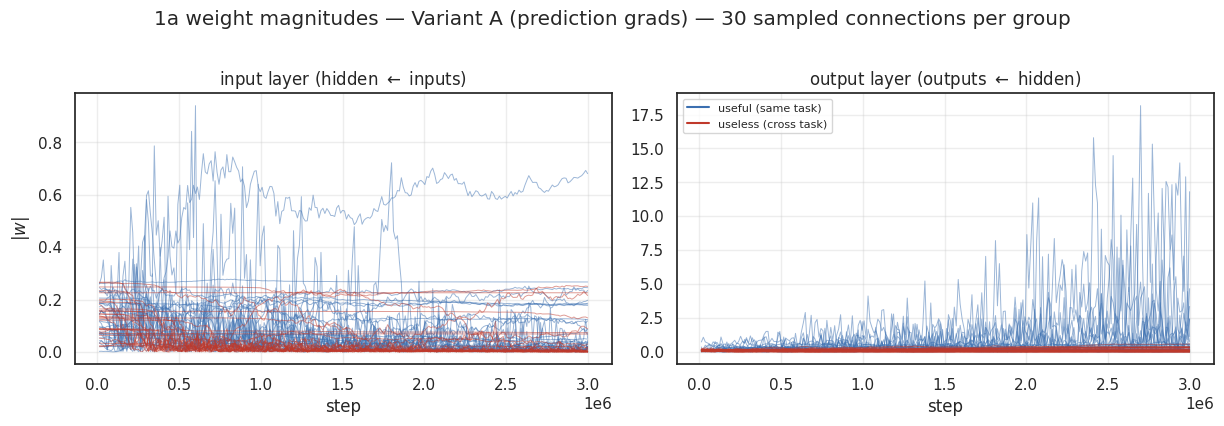

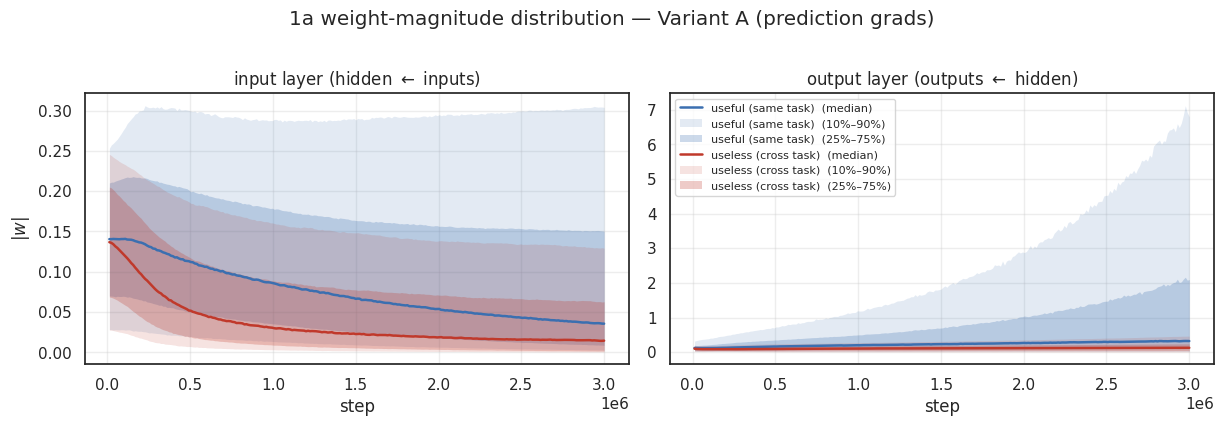

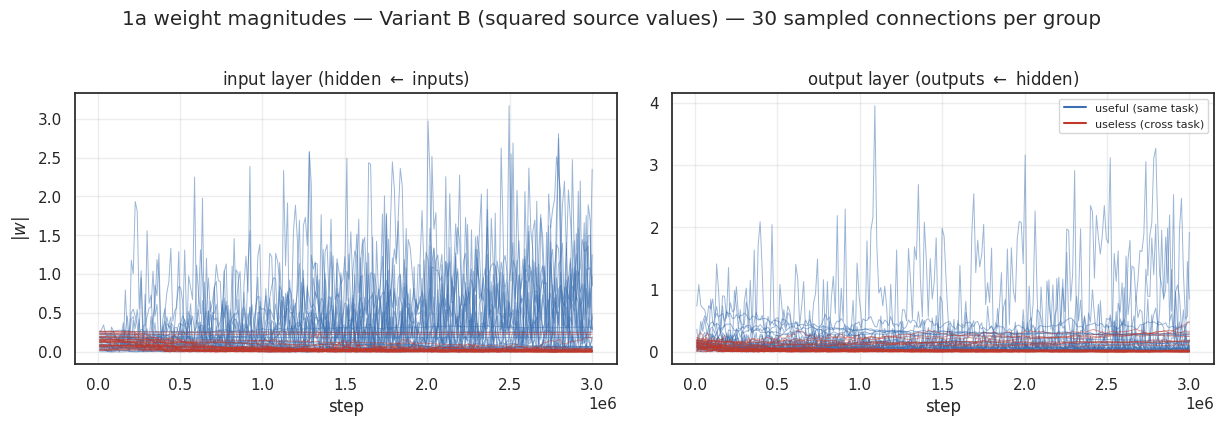

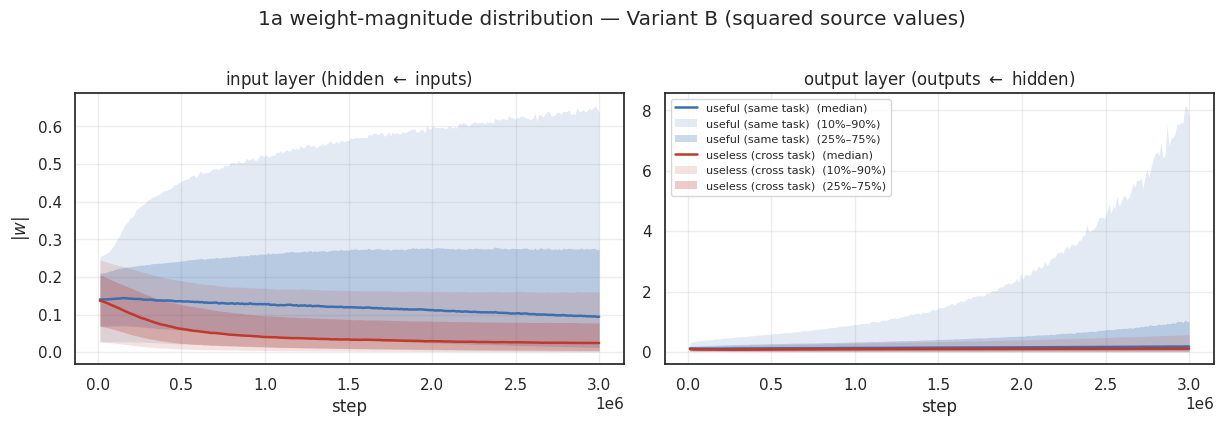

In [14]:
show_figures(traces_1a, EXP_1A_SPECS, GROUP_NAMES_1A, '1a', 'absw')

### 1a — separation summary

The single number the experiment turns on: the ratio of the median useful step-size to the
median useless one, per layer per variant. Greater than 1 means Autostep is separating them.

In [15]:
print(separation_table(traces_1a, EXP_1A_SPECS, ('useful', 'useless'))
      .to_string(index=False, float_format=lambda v: f'{v:.4g}'))

                          variant layer  alpha useful  alpha useless  alpha ratio  |w| useful  |w| useless  |w| ratio
     Variant A (prediction grads)    w1      2.47e-05      1.392e-05        1.775     0.03555      0.01447      2.457
     Variant A (prediction grads)    w2     0.0006616          8e-05        8.269      0.3207       0.1259      2.546
Variant B (squared source values)    w1     4.804e-05      3.745e-05        1.283     0.09463      0.02467      3.837
Variant B (squared source values)    w2      0.000396      6.155e-05        6.434      0.1851       0.1156        1.6


### 1a with L1 regularization

The same experiment once more, with an L1 penalty of `L1_COEFF` on the weights. L1 pushes every
weight toward exactly zero at a constant rate, so the question is whether it *sharpens* the
separation Autostep produces on its own: a useless connection has no gradient signal opposing the
penalty, while a useful one does.

Three things to keep in mind when reading the result:

* The penalty enters the gradient Autostep consumes, so it shapes **step-size adaptation** as well
  as shrinking weights (see `AutostepMLP.step`) — it is not a post-hoc shrinkage.
* The reported loss stays pure squared error, so MSE and FVE are directly comparable to the runs
  above.
* Scale matters. A single L1 step moves a weight by `alpha * L1_COEFF`, which at the initial
  `1e-6` step-size is `1e-8` — negligible — so the penalty only bites once Autostep has grown the
  step-sizes. Its size *relative to the squared-error gradient* is what decides the outcome, and
  that is what the comparison table below is for.

In [ ]:
EXP_1A_L1_SPECS = {
    key: ExpSpec(name=f'exp1a_l1_{key}', label=VARIANT_LABELS[key],
                 fn=lambda n_seeds, n_steps, meta_lr, l1, _v=version: run_1a(
                     meta_lr, _v, n_seeds, n_steps, l1=l1))
    for key, version in VERSIONS.items()
}

for spec in EXP_1A_L1_SPECS.values():
    run_spec_sweep(spec, {'meta_lr': META_LR, 'l1': L1_COEFF}, N_MAIN_SEEDS)

cfgs, runs = load_sweep_data()
traces_1a_l1 = {key: load_traces(DATA_DIR, spec.name) for key, spec in EXP_1A_L1_SPECS.items()}

In [ ]:
plt.figure(figsize=(8, 4.5))
ax = plt.gca()
palette = get_color_palette(n=2 * len(EXP_1A_SPECS))
for offset, (specs, suffix) in enumerate([(EXP_1A_SPECS, 'no L1'),
                                          (EXP_1A_L1_SPECS, f'L1 {L1_COEFF:g}')]):
    for i, spec in enumerate(specs.values()):
        plot_learning_curve(runs, spec.name, label=f'{spec.label} — {suffix}',
                            color=palette[offset * len(specs) + i], ax=ax, n_seeds=N_MAIN_SEEDS)
ax.axhline(BASELINE_MSE, ls='--', c='gray', lw=1, label='mean predictor (FVE 0)')
ax.axhline(IRREDUCIBLE_MSE, ls=':', c='gray', lw=1, label='irreducible (FVE 1)')
ax.set_ylabel('per-output MSE')
ax.set_title(f'1a — with and without L1 ({L1_COEFF:g}), mean ± 95% CI over seeds')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
show_figures(traces_1a_l1, EXP_1A_L1_SPECS, GROUP_NAMES_1A, '1a + L1', 'alpha')
show_figures(traces_1a_l1, EXP_1A_L1_SPECS, GROUP_NAMES_1A, '1a + L1', 'absw')

#### 1a + L1 — does the penalty sharpen the separation?

Both runs side by side. The column to read is `alpha ratio` and `|w| ratio`: larger means the
useful and useless groups are further apart. L1 helping would show up as a larger ratio *and* a
smaller absolute `|w| useless`, without the MSE curve above degrading.

In [ ]:
comparison = pd.concat([
    separation_table(traces_1a, EXP_1A_SPECS, ('useful', 'useless'), run='no L1'),
    separation_table(traces_1a_l1, EXP_1A_L1_SPECS, ('useful', 'useless'),
                     run=f'L1 {L1_COEFF:g}'),
])
print(comparison.to_string(index=False, float_format=lambda v: f'{v:.4g}'))

## Step 3 — how long to pre-train before the 1b injection

1b needs the *level* of performance to be stable before the connectivity changes: under
non-stationarity the weights never stop moving, but the performance recovered after each
permutation should be steady. Run the clean block-sparse structure and read the curve.

[I 2026-07-29 20:17:04,931] A new study created in RDB with name: multi-geoff-experiment-1/blocksparse_pretrain
INFO:mlflow_sweeper.runner:Creating new parent MLflow run: blocksparse_pretrain.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: 1321bd1db9c44b35bbe19ebe51f6e997.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(meta_lr=0.02, n_seeds=10, n_steps=3000000)`
[I 2026-07-29 20:18:23,997] Trial 0 finished with value: 1.4875381570594808 and parameters: {}. Best is trial 0 with value: 1.4875381570594808.
INFO:mlflow_sweeper.runner:Sweep blocksparse_pretrain completed.
INFO:phd.research_utils.scripts.mlflow_download:Tracking URI: postgresql:///mlflow?host=/var/run/postgresql&port=5433
INFO:phd.research_utils.scripts.mlflow_download:Found experiment 'multi-geoff-experiment-1' (id=43)
INFO:phd.research_utils.scripts.mlflow_download:Found 17 runs
INFO:phd.research_utils.scripts.mlflow_download:Discover

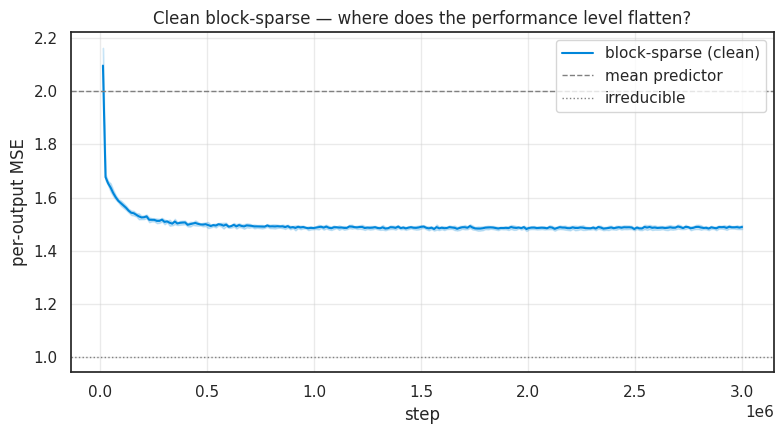

  first within 10% of the final level: step 60000
  first within 5% of the final level: step 120000
  first within 2% of the final level: step 228000


In [16]:
PRETRAIN_SPEC = ExpSpec(
    name='blocksparse_pretrain', label='block-sparse (clean)',
    fn=lambda n_seeds, n_steps, meta_lr: run_1a(
        meta_lr, VERSIONS['variant_b'], n_seeds, n_steps,
        # A clean block-sparse structure has no cross-task connections at all, so 1b's labels
        # are borrowed purely to give the tracing machinery a non-empty second group. Those
        # positions are masked out here, so their snapshots are meaningless and unused — only
        # the loss curve of this run matters.
        masks=base_masks, labels=labels_1b))

run_spec_sweep(PRETRAIN_SPEC, {'meta_lr': META_LR}, N_SWEEP_SEEDS)
cfgs, runs = load_sweep_data()

plt.figure(figsize=(8, 4.5))
ax = plt.gca()
plot_learning_curve(runs, PRETRAIN_SPEC.name, label=PRETRAIN_SPEC.label,
                    color=get_color_palette(n=1)[0], ax=ax, n_seeds=N_SWEEP_SEEDS)
ax.axhline(BASELINE_MSE, ls='--', c='gray', lw=1, label='mean predictor')
ax.axhline(IRREDUCIBLE_MSE, ls=':', c='gray', lw=1, label='irreducible')
ax.set_ylabel('per-output MSE')
ax.set_title('Clean block-sparse — where does the performance level flatten?')
ax.legend()
plt.tight_layout()
plt.show()

# Report where the curve flattens, so N_PRETRAIN_STEPS is read off the data rather than guessed.
rdf = runs[PRETRAIN_SPEC.name].dropna(subset=['loss']).groupby('step')['loss'].mean()
final = rdf.iloc[-len(rdf) // 20:].mean()
for tol in (0.10, 0.05, 0.02):
    within = rdf.index[rdf <= final * (1 + tol)]
    print(f'  first within {tol:.0%} of the final level: step {int(within[0]) if len(within) else "never"}')

In [17]:
# Read off the curve above. Must be a whole multiple of N_SNAPSHOTS.
N_PRETRAIN_STEPS = 1_500_000
print('N_PRETRAIN_STEPS =', N_PRETRAIN_STEPS)

N_PRETRAIN_STEPS = 1500000


## Step 4 — Experiment 1b: bad connections added mid-training

Start from the clean block-sparse structure, train for `N_PRETRAIN_STEPS`, then give every
hidden unit 1–3 new outgoing connections to the other task's outputs and 1–10 new incoming
connections from the other task's inputs. New weights start at zero with the standard 1e-6
step-size; `run_1b` asserts those positions were genuinely untouched beforehand.

The question: do the added connections' step-sizes and weight magnitudes rise, or stay down?

In [18]:
EXP_1B_SPECS = {
    key: ExpSpec(name=f'exp1b_{key}', label=VARIANT_LABELS[key],
                 fn=lambda n_seeds, n_steps, n_pretrain, meta_lr, _v=version: run_1b(
                     meta_lr, _v, n_seeds, n_pretrain, n_steps))
    for key, version in VERSIONS.items()
}

for spec in EXP_1B_SPECS.values():
    run_spec_sweep(spec, {'meta_lr': META_LR, 'n_pretrain': N_PRETRAIN_STEPS}, N_MAIN_SEEDS)

cfgs, runs = load_sweep_data()
traces_1b = {key: load_traces(DATA_DIR, spec.name) for key, spec in EXP_1B_SPECS.items()}

[I 2026-07-29 20:18:24,755] A new study created in RDB with name: multi-geoff-experiment-1/exp1b_variant_a
INFO:mlflow_sweeper.runner:Creating new parent MLflow run: exp1b_variant_a.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: c51cd9ac04244bd4b423c1336ae89e8e.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(meta_lr=0.02, n_pretrain=1500000, n_seeds=30, n_steps=3000000)`
[I 2026-07-29 20:20:36,956] Trial 0 finished with value: 1.4866879846700993 and parameters: {}. Best is trial 0 with value: 1.4866879846700993.
INFO:mlflow_sweeper.runner:Sweep exp1b_variant_a completed.
[I 2026-07-29 20:20:37,041] A new study created in RDB with name: multi-geoff-experiment-1/exp1b_variant_b
INFO:mlflow_sweeper.runner:Creating new parent MLflow run: exp1b_variant_b.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: 7b218dc74e6743f5bb610200c1f0df5c.
INFO:mlflow_sweeper.

### 1b — step-sizes and weights after the connectivity change

Restricted to steps after the injection, per the plan. The x-axis is offset by
`N_PRETRAIN_STEPS` so it reads as absolute training step.

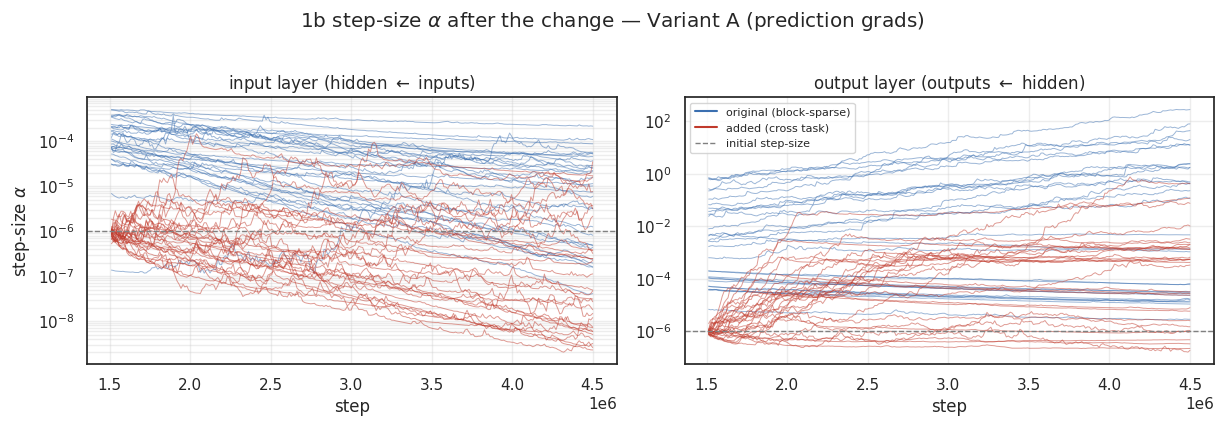

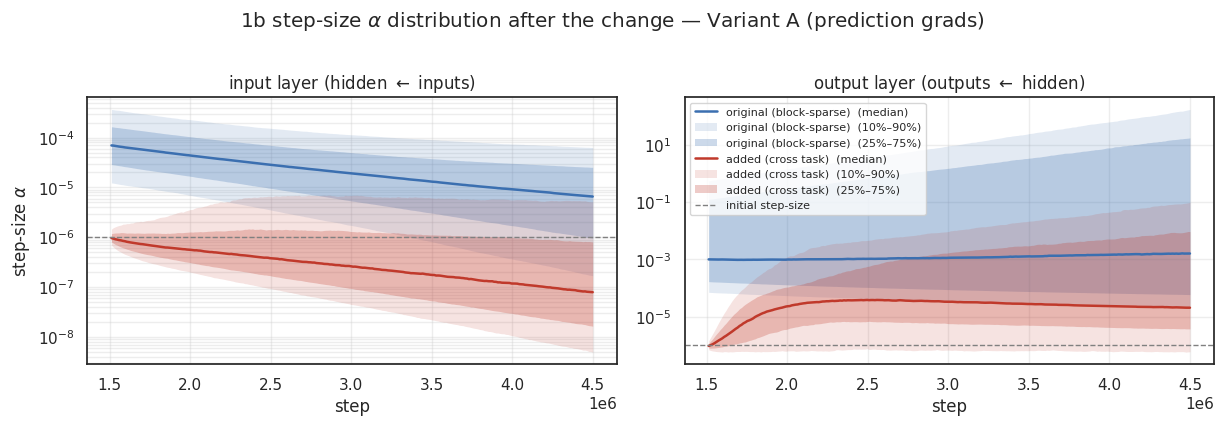

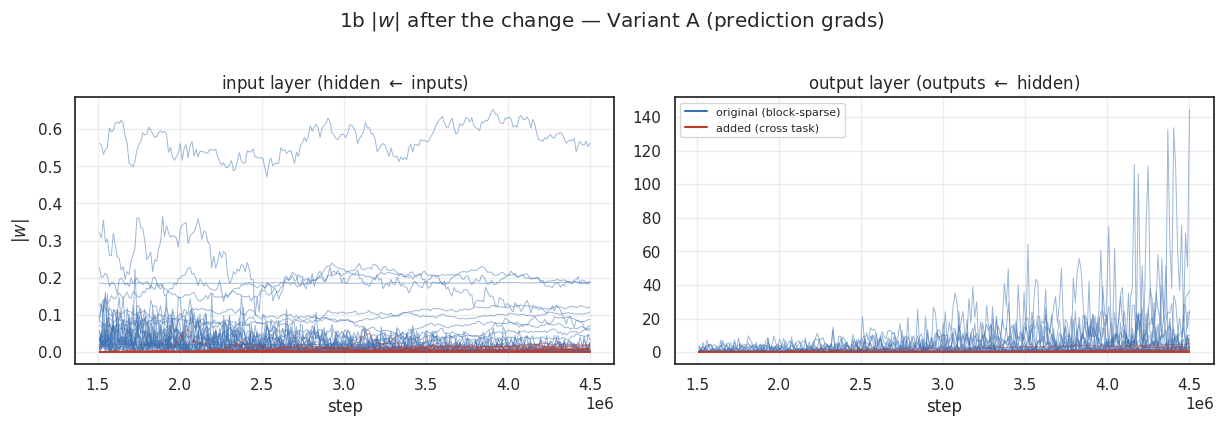

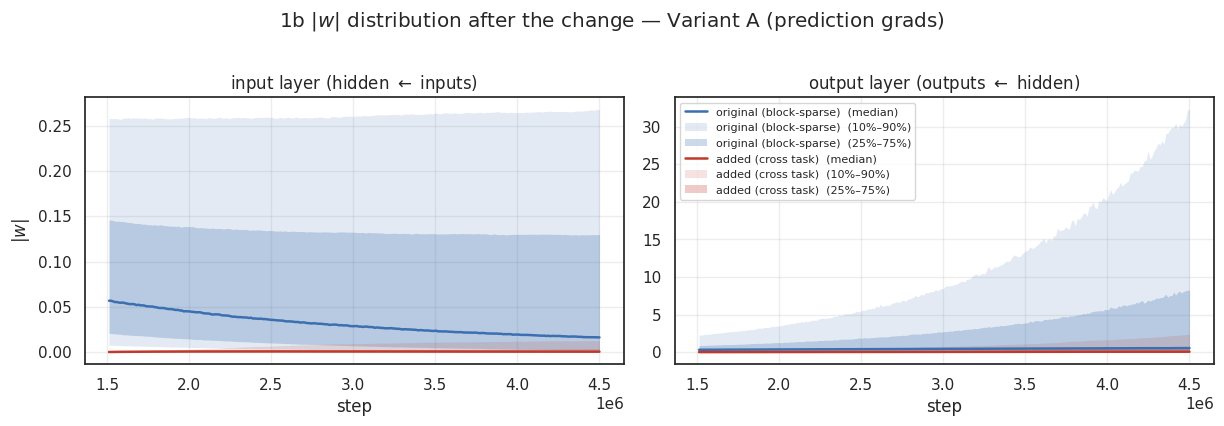

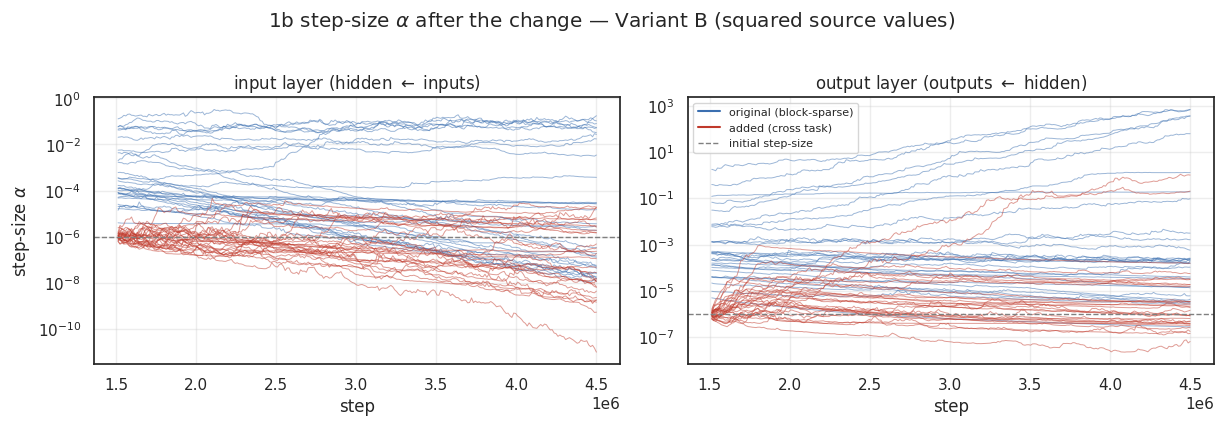

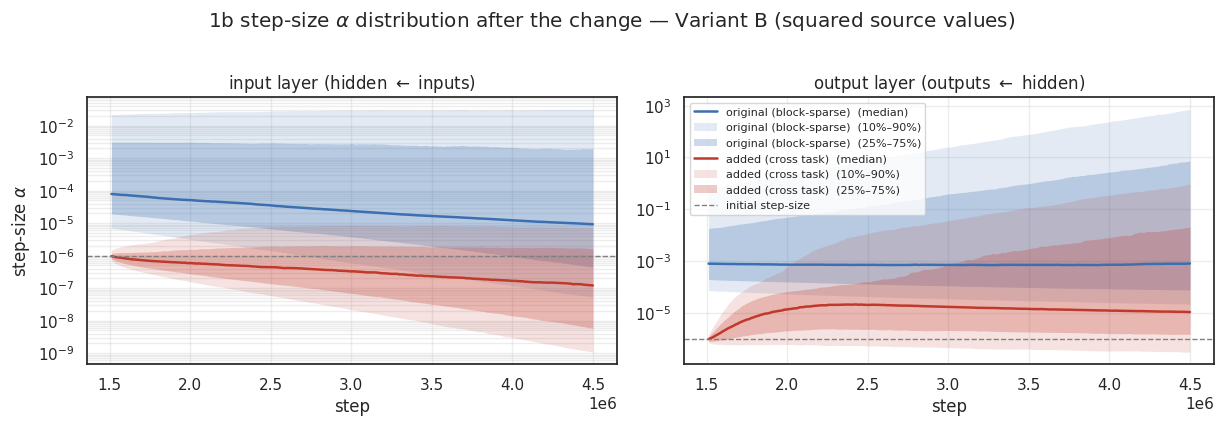

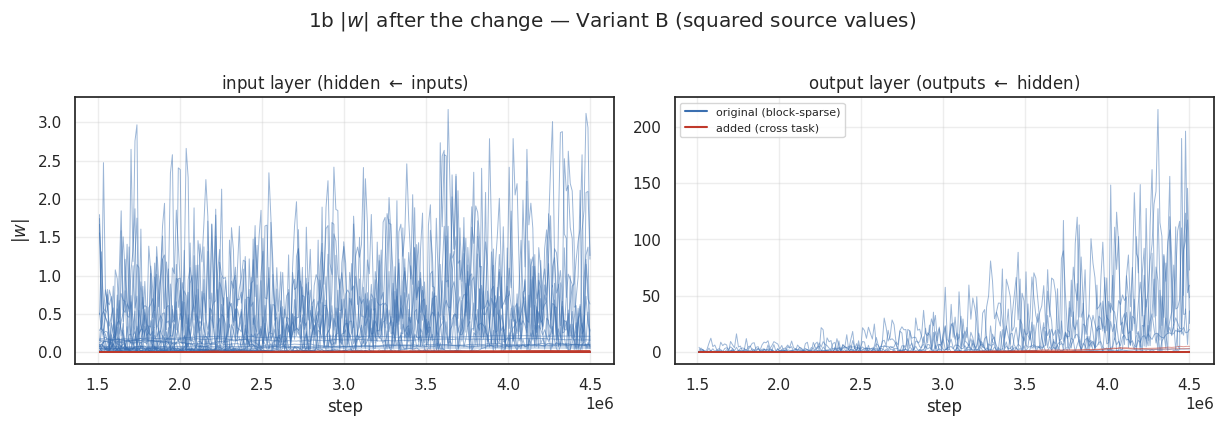

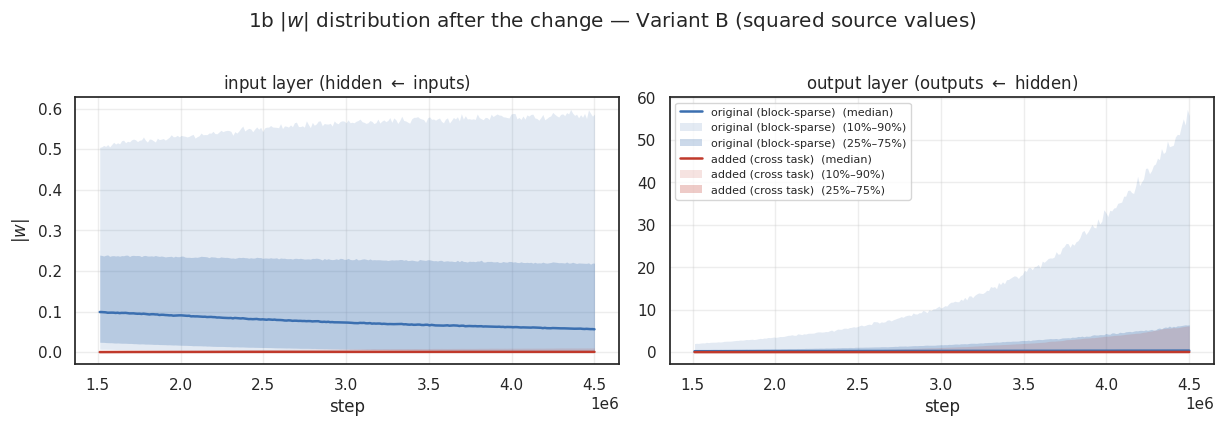

In [19]:
GROUP_NAMES_1B = ('original (block-sparse)', 'added (cross task)')

for key, spec in EXP_1B_SPECS.items():
    t = traces_1b[key]
    for prefix, ylabel, logscale, hline in (
            ('alpha', 'step-size $\\alpha$', True, INIT_LR),
            ('absw', '$|w|$', False, None)):
        plot_traces(t[f'{prefix}_tr'], t['log_steps'], LAYER_NAMES, GROUP_NAMES_1B,
                    f'1b {ylabel} after the change — {spec.label}', ylabel,
                    log_scale=logscale, x_offset=N_PRETRAIN_STEPS, hline=hline)
        plt.show()
        plot_group_bands(t[f'{prefix}_q'], t['log_steps'], LAYER_NAMES, GROUP_NAMES_1B, QUANTILES,
                         f'1b {ylabel} distribution after the change — {spec.label}', ylabel,
                         log_scale=logscale, x_offset=N_PRETRAIN_STEPS, hline=hline)
        plt.show()

### 1b — the whole run, with the injection marked

Not required by the plan, but free: the pre-injection phase was traced with the same labels, and
the injected connections sit at exactly the initial step-size until they are activated. Seeing
the flat baseline and the discontinuity together makes it obvious whether anything moved.

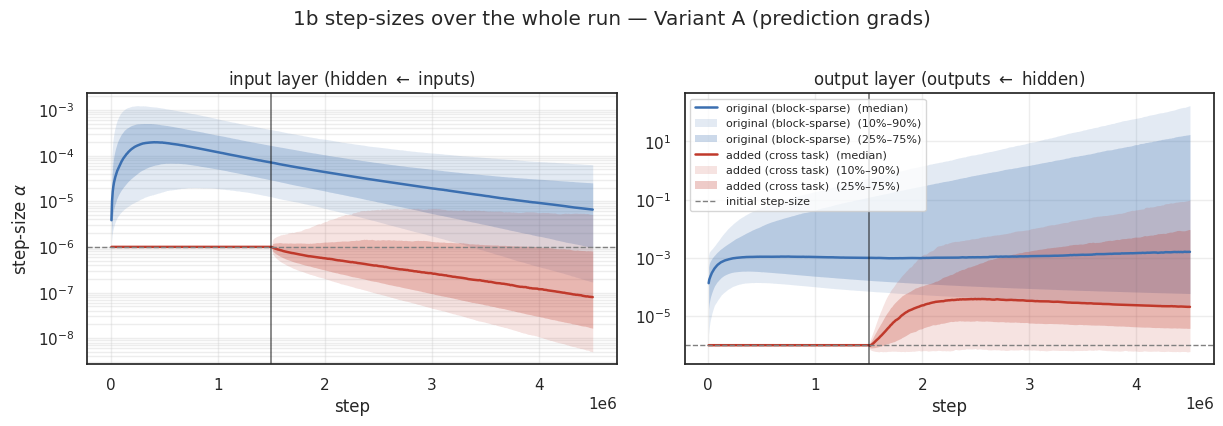

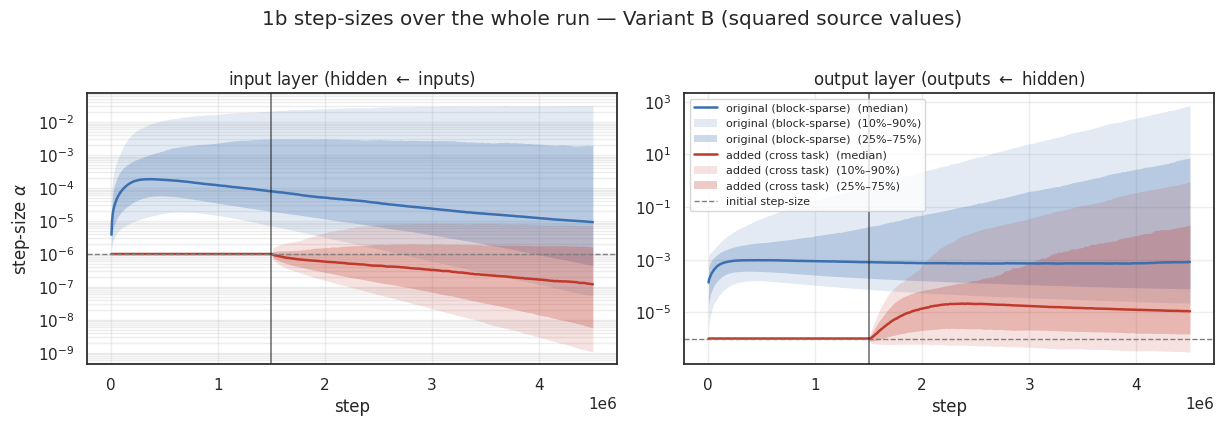

In [20]:
for key, spec in EXP_1B_SPECS.items():
    t = traces_1b[key]
    full_q = np.concatenate([t['pre_alpha_q'], t['alpha_q']], axis=1)
    full_steps = np.concatenate([
        snapshot_steps(N_PRETRAIN_STEPS),
        snapshot_steps(NUM_STEPS) + N_PRETRAIN_STEPS])
    axes = plot_group_bands(full_q, full_steps, LAYER_NAMES, GROUP_NAMES_1B, QUANTILES,
                            f'1b step-sizes over the whole run — {spec.label}',
                            'step-size $\\alpha$', hline=INIT_LR)
    for ax in np.atleast_1d(axes):
        ax.axvline(N_PRETRAIN_STEPS, c='k', lw=1.2, ls='-', alpha=0.6)
    plt.show()

### 1b — separation summary

In [21]:
rows = []
for key, spec in EXP_1B_SPECS.items():
    q = np.asarray(traces_1b[key]['alpha_q'])[:, -1]
    w = np.asarray(traces_1b[key]['absw_q'])[:, -1]
    for li, layer in enumerate(LAYERS):
        rows.append({
            'variant': spec.label, 'layer': layer,
            'alpha original': q[:, li, 0, MEDIAN_IDX].mean(), 'alpha added': q[:, li, 1, MEDIAN_IDX].mean(),
            'alpha ratio': q[:, li, 0, MEDIAN_IDX].mean() / q[:, li, 1, MEDIAN_IDX].mean(),
            'added alpha / init': q[:, li, 1, MEDIAN_IDX].mean() / INIT_LR,
            '|w| original': w[:, li, 0, MEDIAN_IDX].mean(), '|w| added': w[:, li, 1, MEDIAN_IDX].mean(),
        })
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f'{v:.4g}'))

                          variant layer  alpha original  alpha added  alpha ratio  added alpha / init  |w| original  |w| added
     Variant A (prediction grads)    w1       6.575e-06    7.941e-08         82.8             0.07941       0.01625  0.0005161
     Variant A (prediction grads)    w2        0.001611    2.079e-05        77.48               20.79        0.5296      0.054
Variant B (squared source values)    w1       9.236e-06    1.206e-07        76.59              0.1206       0.05625  0.0005708
Variant B (squared source values)    w2       0.0008075    1.087e-05        74.26               10.87        0.3535     0.0295


## What to take from this

Read the figures against the prediction the plan makes:

* **1a** — useful connections' step-sizes should rise above the 1e-6 start while useless ones
  stay near it. The distribution panels matter more than the traces: a handful of useless
  connections escaping is tolerable, the bulk moving is not.
* **1b** — the added connections should hold near 1e-6 with weights near 0. They are the
  cleaner test, because they are bad-but-not-useless and so have a real incentive to move.
* **A vs B** — the variants are numerically identical while step-sizes are small (see the note
  in the configuration cell) and only separate once they have grown. If they look the same,
  check that the step-sizes actually left 1e-6 before concluding anything about the variants.
* If Variant A's first-layer step-sizes look frozen, check the second layer's initialization —
  a near-zero second layer zeroes Variant A's first-layer prediction gradients.

Everything after this notebook uses Variant A per the plan, and the meta step-size chosen in
step 1. The follow-ups the plan notes but does not schedule (adding an irrelevant feature
mid-training with vs. without Autostep; ablating how the *number* of added connections affects
any rise) are not implemented here.